<center>
    <h1>Análisis exploratorio de datos del Covid-19 en Colombia</h1>
</center>

<h2>
    Autor: Felipe Fernández Rodriguez
</h2>

In [ ]:
# Librerías necesarias para el análisis de datos y visualización
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Librería para descargar archivos desde una URL
import requests
import os

# Definir la ruta y el nombre del archivo a descargar
filename = 'Casos_positivos_de_COVID-19_en_Colombia.csv'
path = os.path.join(os.getcwd(), 'data', filename)

# Función para descargar un archivo desde una URL y guardarlo localmente
def download(url, filename):    

    try:
        response = requests.get(url)
        response.raise_for_status()  # Lanza excepción si el status_code no es 2xx

        with open(path, 'wb') as file:
            file.write(response.content)

        print(f"Descarga completada: {path}")
        return True, path

    except requests.exceptions.HTTPError as e:
        print(f"Error HTTP ({response.status_code}) al descargar: {e}")
        return False, str(e)
    except requests.exceptions.RequestException as e:
        print(f"Error de red o URL inválida: {e}")
        return False, str(e)
    except OSError as e:
        print(f"Error al escribir el archivo: {e}")
        return False, str(e)

# URL del archivo CSV a descargar
url = 'https://www.datos.gov.co/api/views/gt2j-8ykr/rows.csv?accessType=DOWNLOAD&bom=true&format=true'

# Descargar el archivo CSV desde la URL
download(url, filename)

Descarga completada: c:\Users\pipef\OneDrive - IU Digital de Antioquia\Documentos\IUDigital\Analitica_de_Datos\data\Casos_positivos_de_COVID-19_en_Colombia.csv


(True,
 'c:\\Users\\pipef\\OneDrive - IU Digital de Antioquia\\Documentos\\IUDigital\\Analitica_de_Datos\\data\\Casos_positivos_de_COVID-19_en_Colombia.csv')

In [6]:
# Cargar el archivo CSV en un DataFrame de pandas
data_covid = pd.read_csv(path)

C:\Users\pipef\AppData\Local\Temp\ipykernel_6940\1473820893.py:2: DtypeWarning: Columns (0: Código ISO del país, 1: Nombre del país) have mixed types. Specify dtype option on import or set low_memory=False.
  data_covid = pd.read_csv(path)


In [7]:
# Mostrar cantidad de filas y columnas del DataFrame
data_covid.shape

(6390971, 23)

<h3>📊 Descripción de la Estructura del Dataset</h3>
<p>Al ejecutar el método <code>data_covid.shape</code>, se identifica la dimensionalidad del conjunto de datos sobre COVID-19 en Colombia:</p>
    
<table style="width: 100%; border-collapse: collapse; margin-top: 10px;">
    <tr style="background-color: #007bff; color: white;">
        <th style="padding: 10px; border: 1px solid #ddd; text-align: left;">Dimensión</th>
        <th style="padding: 10px; border: 1px solid #ddd; text-align: left;">Valor Encontrado</th>
        <th style="padding: 10px; border: 1px solid #ddd; text-align: left;">Descripción</th>
    </tr>
    <tr>
        <td style="padding: 10px; border: 1px solid #ddd;"><b>Filas (Registros)</b></td>
        <td style="padding: 10px; border: 1px solid #ddd;">6,390,971</td>
        <td style="padding: 10px; border: 1px solid #ddd;">Representa el total de casos individuales reportados en el territorio nacional.</td>
    </tr>
    <tr>
        <td style="padding: 10px; border: 1px solid #ddd;"><b>Columnas (Variables)</b></td>
        <td style="padding: 10px; border: 1px solid #ddd;">23</td>
        <td style="padding: 10px; border: 1px solid #ddd;">Atributos que describen cada caso (ubicación, fechas, estado de salud, etnia, etc.).</td>
    </tr>
</table>

<p style="margin-top: 15px;">
    <strong>Interpretación:</strong> El dataset posee un volumen considerable de información, lo que permite realizar un análisis estadístico robusto. La presencia de 23 variables sugiere una estructura rica en datos.
</p>

In [ ]:
# Mostrar información general del DataFrame
data_covid.info(verbose = True, show_counts = True)

<class 'pandas.DataFrame'>
RangeIndex: 6390971 entries, 0 to 6390970
Data columns (total 23 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   fecha reporte web             6390971 non-null  str    
 1   ID de caso                    6390971 non-null  str    
 2   Fecha de notificación         6390971 non-null  str    
 3   Código DIVIPOLA departamento  6390971 non-null  str    
 4   Nombre departamento           6390971 non-null  str    
 5   Código DIVIPOLA municipio     6390971 non-null  str    
 6   Nombre municipio              6390971 non-null  str    
 7   Edad                          6390971 non-null  int64  
 8   Unidad de medida de edad      6390971 non-null  int64  
 9   Sexo                          6390971 non-null  str    
 10  Tipo de contagio              6390971 non-null  str    
 11  Ubicación del caso            6349703 non-null  str    
 12  Estado                        6349703 n

<h3 >📋 Análisis Estructural del DataFrame (.info)</h3>

<p>Tras la ejecución del método <code>data_covid.info(verbose=True, show_counts=True)</code>, se extraen las siguientes conclusiones sobre la composición técnica del conjunto de datos:</p>

<ul style="line-height: 1.6;">
    <li><b style="color: #2980b9;">Volumen de Memoria:</b> El dataset demanda más de <b>1.1 GB</b> de memoria RAM, lo que confirma que estamos ante un volumen de datos masivo que requiere un procesamiento eficiente.</li>
    <li><b style="color: #2980b9;">Composición de Tipos de Datos (Dtypes):</b> 
        Se identifican 23 columnas distribuidas de la siguiente manera:
        <ul>
            <li><b>Cadenas de texto (str/object):</b> 20 columnas. La mayoría de las fechas y categorías están en este formato.</li>
            <li><b>Numéricos (int64/float64):</b> 3 columnas (Edad, Unidad de medida y Pertenencia étnica).</li>
        </ul>
    </li>
    <li><b style="color: #2980b9;">Presencia de Valores Nulos (Anomalías detectadas):</b> 
        Aunque el dataset tiene 6,390,971 registros, existen columnas con una alta tasa de datos faltantes, lo cual es crítico para realizar un correcto perfilado de los datos</b>:
        <ul>
            <li><b>Fecha de inicio de síntomas:</b> Cuenta con 5,885,587 registros no nulos. Existen aproximadamente <b>505,384 valores faltantes (NaN)</b>. Esto ocurre comúnmente en casos asintomáticos o registros donde el paciente no pudo precisar el inicio del malestar.</li>
            <li><b>Código ISO del país:</b> Solo cuenta con <b>3,710 registros no nulos</b>. Esto representa menos del 0.1% del total del dataset.</li>
            <li><b>Nombre del grupo étnico:</b> Solo 83,864 registros tienen esta información.</li>
        </ul>
    </li>
</ul>

<div>
    <strong>Nota:</strong> Las columnas de fechas (como <i>fecha reporte web</i> o <i>Fecha de notificación</i>) están siendo reconocidas como <code>str</code> (texto). Para realizar análisis temporales avanzados, se recomienda transformarlas posteriormente al tipo <code>datetime64</code>.
</div>

In [16]:
# Mostrar estadísticas descriptivas del DataFrame
data_covid.describe(include = 'all').round(2)

,fecha reporte web,ID de caso,Fecha de notificación,Código DIVIPOLA departamento,Nombre departamento,Código DIVIPOLA municipio,Nombre municipio,Edad,Unidad de medida de edad,Sexo,...,Código ISO del país,Nombre del país,Recuperado,Fecha de inicio de síntomas,Fecha de muerte,Fecha de diagnóstico,Fecha de recuperación,Tipo de recuperación,Pertenencia étnica,Nombre del grupo étnico
count,6390971,6390971,6390971,6390971,6390971,6390971,6390971,6390971.00,6390971.00,6390971,...,3710.0,3718,6354644,5885587,184393,6388216,6208647,6208573,6388815.00,83864
unique,872,6390971,1413,36,41,1121,1057,NaN,NaN,4,...,121.0,89,4,1419,1391,1410,969,3,NaN,1887
top,2022-01-15 00:00:00,"1,556,979",2022-01-06 00:00:00,11,BOGOTA,"11,001",BOGOTA,NaN,NaN,F,...,840.0,ESTADOS UNIDOS DE AMÉRICA,Recuperado,2022-01-03 00:00:00,2021-06-21 00:00:00,2022-01-07 00:00:00,2021-06-15 00:00:00,Tiempo,NaN,Por definir
freq,35576,1,44424,1888137,1888137,1888137,1888137,NaN,NaN,3417087,...,1369.0,1418,6208573,41484,716,42180,61040,5274348,NaN,17222
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.98,1.01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.91,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.47,0.08,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.59,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,1.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.00,1.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.00,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.00,1.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.00,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53.00,1.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.00,NaN


<h3 >🧠 Hallazgos del Análisis Descriptivo</h3>

<p>El análisis descriptivo integral revela una estructura de datos donde la información <b>cualitativa</b> predomina sobre la cuantitativa. A continuación, los hallazgos más relevantes:</p>

<table>
    <thead>
        <tr style="background-color: #007bff; color: white;">
            <th style="padding: 10px; border: 1px solid #ddd;">Dimensión</th>
            <th style="padding: 10px; border: 1px solid #ddd;">Interpretación de los Resultados</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd;"><b>Perfil Demográfico (Edad)</b></td>
            <td style="padding: 10px; border: 1px solid #ddd;">
                La media de edad es de <b>39.98 años</b> con una desviación estándar de <b>18.47</b>. El 50% de la población afectada (mediana) tiene 38 años o menos, lo que indica que el virus impactó mayoritariamente a la población adulta joven y en edad laboral. El valor máximo de 114 años sugiere la presencia de <i>outliers</i> o registros excepcionales de longevidad.
            </td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd;"><b>Predominancia Categórica</b></td>
            <td style="padding: 10px; border: 1px solid #ddd;">
                Variables como <b>Sexo (Top: F con 3.4M)</b> y <b>Ubicación (Top: Bogotá con 1.8M)</b> muestran que la base de datos se comporta como un inventario de frecuencias. El hecho de que el valor "top" en sexo sea Femenino sugiere una mayor incidencia reportada en mujeres en el consolidado nacional.
            </td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd;"><b>Naturaleza del Contagio</b></td>
            <td style="padding: 10px; border: 1px solid #ddd;">
                La variable <code>Tipo de contagio</code> tiene como categoría principal <b>Comunitaria</b> (4.4M registros). Esto demuestra que, para el momento del corte de los datos, el rastro epidemiológico se había perdido en la mayoría de los casos, superando por mucho a los casos "Relacionados".
            </td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd;"><b>Salud de los Datos (Anomalías)</b></td>
            <td style="padding: 10px; border: 1px solid #ddd;">
                Se observa una alta dispersión en <code>Nombre del país</code> y <code>Nombre del grupo étnico</code> (NaN masivos). Además, existen inconsistencias en las etiquetas (ej. 'Leve' vs 'leve', 'F' vs 'f'), lo que requeriría una normalización de texto (limpieza de datos) antes de realizar modelos predictivos.
            </td>
        </tr>
    </tbody>
</table>

In [15]:
# Mostrar estadísticas descriptivas del DataFrame
data_covid.describe().round(2)

,Edad,Unidad de medida de edad,Pertenencia étnica
count,6390971.00,6390971.00,6388815.00
mean,39.98,1.01,5.91
std,18.47,0.08,0.59
min,1.00,1.00,1.00
25%,27.00,1.00,6.00
50%,38.00,1.00,6.00
75%,53.00,1.00,6.00
max,114.00,5.00,6.00


<h3>📉 Interpretación de Estadísticos Descriptivos (Numéricos)</h3>

<p>A partir de los resultados obtenidos con <code>.describe()</code>, se analizan las tres variables cuantitativas del dataset:</p>

<b style="color: #2980b9;">1. Variable Edad:</b>
<ul style="margin-top: 5px;">
    <li><b>Media (39.98 años):</b> El promedio de edad de los contagiados ronda los 40 años, lo que sitúa el impacto principal en la población adulta joven.</li>
    <li><b>Mediana (38.00 años):</b> Al ser muy cercana a la media, indica que la distribución de edades es relativamente simétrica, aunque ligeramente sesgada hacia los jóvenes. El 50% de los casos ocurrió en personas menores de 38 años.</li>
    <li><b>Dispersión (std 18.47):</b> Existe una variabilidad moderada; hay casos en casi todos los rangos de edad.</li>
    <li><b>Valores Extremos (min 1 / max 114):</b> El dataset incluye desde bebés de 1 año hasta personas de 114 años. (Nota: Valores de 114 años podrían ser <i>outliers</i> o registros excepcionales de longevidad).</li>
</ul>


<b style="color: #2980b9;">2. Unidad de medida de edad:</b>
<ul style="margin-top: 5px;">
    <li>La media de <b>1.01</b> y el hecho de que el percentil 75% sea <b>1.00</b> indica que la inmensa mayoría de los registros están medidos en <b>Años</b> (codificado usualmente como 1). Los valores máximos de 5 sugieren que existen otras unidades (Meses, Días) para casos pediátricos.</li>
</ul>


<b style="color: #2980b9;">3. Pertenencia étnica:</b>
<ul style="margin-top: 5px;">
    <li>El valor <b>6.00</b> domina desde el percentil 25% hasta el 75%. En la codificación del Ministerio de Salud, el 6 corresponde a "Otros / No pertenece a grupo étnico". Esto significa que la vasta mayoría de la población contagiada no se auto-identifica con una etnia minoritaria específica.</li>
</ul>

In [19]:
# Primeros registros del DataFrame
data_covid.head(10)

,fecha reporte web,ID de caso,Fecha de notificación,Código DIVIPOLA departamento,Nombre departamento,Código DIVIPOLA municipio,Nombre municipio,Edad,Unidad de medida de edad,Sexo,...,Código ISO del país,Nombre del país,Recuperado,Fecha de inicio de síntomas,Fecha de muerte,Fecha de diagnóstico,Fecha de recuperación,Tipo de recuperación,Pertenencia étnica,Nombre del grupo étnico
0,2020-12-24 00:00:00,"1,556,979",2020-12-22 00:00:00,76,VALLE,"76,001",CALI,67,1,F,...,NaN,NaN,Recuperado,2020-12-21 00:00:00,NaN,2020-12-23 00:00:00,2021-01-04 00:00:00,Tiempo,6.0,NaN
1,2020-12-24 00:00:00,"1,556,980",2020-12-19 00:00:00,76,VALLE,"76,001",CALI,66,1,F,...,NaN,NaN,Recuperado,2020-12-07 00:00:00,NaN,2020-12-23 00:00:00,2020-12-25 00:00:00,Tiempo,6.0,NaN
2,2020-12-24 00:00:00,"1,556,981",2020-12-19 00:00:00,76,VALLE,"76,001",CALI,68,1,F,...,NaN,NaN,Recuperado,2020-12-18 00:00:00,NaN,2020-12-22 00:00:00,2021-01-01 00:00:00,Tiempo,6.0,NaN
3,2020-12-24 00:00:00,"1,556,982",2020-12-22 00:00:00,76,VALLE,"76,001",CALI,74,1,F,...,NaN,NaN,Fallecido,2020-12-17 00:00:00,2020-12-30 00:00:00,2020-12-23 00:00:00,NaN,NaN,6.0,NaN
4,2020-12-24 00:00:00,"1,556,983",2020-12-22 00:00:00,76,VALLE,"76,001",CALI,65,1,F,...,NaN,NaN,Recuperado,2020-12-21 00:00:00,NaN,2020-12-23 00:00:00,2021-01-04 00:00:00,Tiempo,6.0,NaN
5,2020-12-24 00:00:00,"1,556,984",2020-12-15 00:00:00,76,VALLE,"76,001",CALI,66,1,F,...,NaN,NaN,Recuperado,2020-12-09 00:00:00,NaN,2020-12-23 00:00:00,2020-12-25 00:00:00,Tiempo,6.0,NaN
6,2020-12-24 00:00:00,"1,556,985",2020-12-21 00:00:00,76,VALLE,"76,001",CALI,74,1,F,...,NaN,NaN,Recuperado,2020-12-14 00:00:00,NaN,2020-12-22 00:00:00,2020-12-28 00:00:00,Tiempo,6.0,NaN
7,2020-12-24 00:00:00,"1,556,986",2020-12-18 00:00:00,76,VALLE,"76,001",CALI,66,1,F,...,NaN,NaN,Fallecido,2020-12-11 00:00:00,2020-12-26 00:00:00,2020-12-22 00:00:00,NaN,NaN,6.0,NaN
8,2020-12-24 00:00:00,"1,556,987",2020-12-18 00:00:00,76,VALLE,"76,001",CALI,64,1,F,...,NaN,NaN,Recuperado,2020-12-15 00:00:00,NaN,2020-12-23 00:00:00,2020-12-30 00:00:00,Tiempo,6.0,NaN
9,2020-12-24 00:00:00,"1,556,988",2020-12-17 00:00:00,76,VALLE,"76,001",CALI,65,1,F,...,NaN,NaN,Recuperado,2020-12-08 00:00:00,NaN,2020-12-22 00:00:00,2020-12-25 00:00:00,Tiempo,6.0,NaN


In [20]:
# Ultimos registros del DataFrame
data_covid.tail(10)

,fecha reporte web,ID de caso,Fecha de notificación,Código DIVIPOLA departamento,Nombre departamento,Código DIVIPOLA municipio,Nombre municipio,Edad,Unidad de medida de edad,Sexo,...,Código ISO del país,Nombre del país,Recuperado,Fecha de inicio de síntomas,Fecha de muerte,Fecha de diagnóstico,Fecha de recuperación,Tipo de recuperación,Pertenencia étnica,Nombre del grupo étnico
6390961,2021-10-24 00:00:00,"4,990,081",2021-10-21 00:00:00,76,VALLE,"76,520",PALMIRA,42,1,F,...,NaN,NaN,Recuperado,2021-10-15 00:00:00,NaN,2021-10-23 00:00:00,2021-10-29 00:00:00,Tiempo,6.0,NaN
6390962,2021-10-24 00:00:00,"4,990,082",2021-10-21 00:00:00,76,VALLE,"76,520",PALMIRA,38,1,F,...,NaN,NaN,Recuperado,2021-10-17 00:00:00,NaN,2021-10-21 00:00:00,2021-10-31 00:00:00,Tiempo,6.0,NaN
6390963,2021-10-24 00:00:00,"4,990,085",2021-10-19 00:00:00,76,VALLE,"76,400",LA UNION,50,1,F,...,NaN,NaN,Recuperado,2021-10-16 00:00:00,NaN,2021-10-23 00:00:00,2021-10-30 00:00:00,Tiempo,6.0,NaN
6390964,2021-10-24 00:00:00,"4,990,086",2021-10-22 00:00:00,76,VALLE,"76,834",TULUA,51,1,M,...,NaN,NaN,Recuperado,2021-10-21 00:00:00,NaN,2021-10-23 00:00:00,2021-11-04 00:00:00,Tiempo,6.0,NaN
6390965,2021-10-24 00:00:00,"4,990,087",2021-10-20 00:00:00,76,VALLE,"76,563",PRADERA,21,1,F,...,NaN,NaN,Recuperado,2021-10-13 00:00:00,NaN,2021-10-23 00:00:00,2021-10-27 00:00:00,Tiempo,6.0,NaN
6390966,2021-10-24 00:00:00,"4,990,088",2021-10-19 00:00:00,76,VALLE,"76,520",PALMIRA,37,1,M,...,NaN,NaN,Recuperado,2021-10-13 00:00:00,NaN,2021-10-23 00:00:00,2021-10-27 00:00:00,Tiempo,6.0,NaN
6390967,2021-10-24 00:00:00,"4,990,091",2021-10-23 00:00:00,76,VALLE,"76,520",PALMIRA,36,1,M,...,NaN,NaN,Recuperado,2021-10-16 00:00:00,NaN,2021-10-23 00:00:00,2021-10-30 00:00:00,Tiempo,6.0,NaN
6390968,2021-10-24 00:00:00,"4,990,092",2021-10-19 00:00:00,76,VALLE,"76,364",JAMUNDI,39,1,F,...,NaN,NaN,Recuperado,2021-10-18 00:00:00,NaN,2021-10-23 00:00:00,2021-11-01 00:00:00,Tiempo,6.0,NaN
6390969,2021-10-24 00:00:00,"4,990,095",2021-11-05 00:00:00,76,VALLE,"76,364",JAMUNDI,43,1,F,...,NaN,NaN,Recuperado,2021-10-21 00:00:00,NaN,2021-10-23 00:00:00,2021-11-04 00:00:00,PCR,6.0,NaN
6390970,2021-10-24 00:00:00,"4,990,096",2021-10-22 00:00:00,76,VALLE,"76,364",JAMUNDI,16,1,M,...,NaN,NaN,Recuperado,2021-10-21 00:00:00,NaN,2021-10-23 00:00:00,2021-11-04 00:00:00,PCR,6.0,NaN


In [21]:
# Datos aleatorios del DataFrame
data_covid.sample(10)

,fecha reporte web,ID de caso,Fecha de notificación,Código DIVIPOLA departamento,Nombre departamento,Código DIVIPOLA municipio,Nombre municipio,Edad,Unidad de medida de edad,Sexo,...,Código ISO del país,Nombre del país,Recuperado,Fecha de inicio de síntomas,Fecha de muerte,Fecha de diagnóstico,Fecha de recuperación,Tipo de recuperación,Pertenencia étnica,Nombre del grupo étnico
2802257,2020-11-06 00:00:00,"1,120,994",2020-10-25 00:00:00,5,ANTIOQUIA,"5,001",MEDELLIN,23,1,F,...,NaN,NaN,Recuperado,2020-10-21 00:00:00,NaN,2020-11-05 00:00:00,2020-11-07 00:00:00,PCR,6.0,NaN
4497920,2021-06-22 00:00:00,"3,969,278",2021-06-10 00:00:00,54,NORTE SANTANDER,"54,001",CUCUTA,68,1,M,...,NaN,NaN,Recuperado,2021-06-06 00:00:00,NaN,2021-06-21 00:00:00,2021-06-23 00:00:00,Tiempo,6.0,NaN
1054074,2021-05-21 00:00:00,"3,177,660",2021-05-19 00:00:00,8,ATLANTICO,"8,758",SOLEDAD,23,1,M,...,NaN,NaN,Recuperado,2021-05-15 00:00:00,NaN,2021-05-19 00:00:00,2021-05-29 00:00:00,Tiempo,6.0,NaN
5194066,2021-12-07 00:00:00,"5,083,066",2021-11-24 00:00:00,63,QUINDIO,"63,001",ARMENIA,46,1,M,...,NaN,NaN,Recuperado,2021-11-19 00:00:00,NaN,2021-12-05 00:00:00,2021-12-08 00:00:00,Tiempo,6.0,NaN
2750489,2020-08-16 00:00:00,"459,588",2020-08-09 00:00:00,73,TOLIMA,"73,001",IBAGUE,40,1,F,...,NaN,NaN,Recuperado,2020-08-03 00:00:00,NaN,2020-08-15 00:00:00,2020-08-28 00:00:00,Tiempo,6.0,NaN
2076999,2020-12-04 00:00:00,"1,344,816",2020-11-30 00:00:00,25,CUNDINAMARCA,"25,126",CAJICA,43,1,F,...,NaN,NaN,Recuperado,2020-11-21 00:00:00,NaN,2020-12-01 00:00:00,2020-12-06 00:00:00,Tiempo,6.0,NaN
5642036,2023-02-22 00:00:00,"6,359,499",2022-12-11 00:00:00,11,BOGOTA,"11,001",BOGOTA,5,2,M,...,NaN,NaN,Recuperado,NaN,NaN,2022-12-12 00:00:00,2023-03-01 00:00:00,Tiempo,6.0,NaN
526013,2021-05-29 00:00:00,"3,354,721",2021-05-26 00:00:00,11,BOGOTA,"11,001",BOGOTA,14,1,F,...,NaN,NaN,Recuperado,2021-05-23 00:00:00,NaN,2021-05-27 00:00:00,2021-06-07 00:00:00,Tiempo,6.0,NaN
4814662,2020-08-17 00:00:00,"468,744",2020-08-12 00:00:00,25,CUNDINAMARCA,"25,175",CHIA,53,1,M,...,NaN,NaN,Recuperado,2020-08-04 00:00:00,NaN,2020-08-16 00:00:00,2021-04-25 00:00:00,PCR,6.0,NaN
4496745,2021-06-19 00:00:00,"3,914,055",2021-06-16 00:00:00,11,BOGOTA,"11,001",BOGOTA,16,1,F,...,NaN,NaN,Recuperado,2021-06-12 00:00:00,NaN,2021-06-16 00:00:00,2021-06-26 00:00:00,Tiempo,6.0,NaN


In [22]:
# Columnas del DataFrame
data_covid.columns

Index(['fecha reporte web', 'ID de caso', 'Fecha de notificación',
       'Código DIVIPOLA departamento', 'Nombre departamento',
       'Código DIVIPOLA municipio', 'Nombre municipio', 'Edad',
       'Unidad de medida de edad', 'Sexo', 'Tipo de contagio',
       'Ubicación del caso', 'Estado', 'Código ISO del país',
       'Nombre del país', 'Recuperado', 'Fecha de inicio de síntomas',
       'Fecha de muerte', 'Fecha de diagnóstico', 'Fecha de recuperación',
       'Tipo de recuperación', 'Pertenencia étnica',
       'Nombre del grupo étnico'],
      dtype='str')

In [ ]:
# Lista de columnas para analizar valores únicos
columns = ['Estado', 'Sexo', 'Tipo de contagio', 'Nombre del país', 'Tipo de recuperación', 'Pertenencia étnica', 'Nombre del grupo étnico']

# Imprimir la cantidad de valores únicos en cada columna
for column in columns:
    if column in data_covid.columns:
        print(f"{data_covid[column].value_counts(dropna = False)}\n")
    else:
        print(f"'{column}' no se encuentra en el DataFrame.")

Estado
Leve         6154791
Fallecido     143125
leve           50623
NaN            41268
Moderado        1056
Grave            106
LEVE               2
Name: count, dtype: int64

Sexo
F    3417087
M    2973872
f          6
m          6
Name: count, dtype: int64

Tipo de contagio
Comunitaria    4447740
Relacionado    1939528
Importado         3703
Name: count, dtype: int64

Nombre del país
NaN                            6387253
ESTADOS UNIDOS DE AMÉRICA         1418
MÉXICO                             385
ESPAÑA                             370
BRASIL                             285
                                ...   
SAN BARTOLOMÉ                        1
VENEUELA                             1
REPUBLICA POPULAR DEL CONGO          1
REPÚBLICA CHECA                      1
HAITÍ                                1
Name: count, Length: 90, dtype: int64

Tipo de recuperación
Tiempo    5274348
PCR        933773
NaN        182398
TIEMPO        452
Name: count, dtype: int64

Pertenencia étnica

<h3>📋 Diagnóstico por Variable (value_counts)</h3>

<b style="color: #2980b9;">1. Estado (Anomalía Crítica de Consistencia):</b>
<p>Se observa una falta de estandarización en el registro. La categoría "Leve" aparece de tres formas distintas: <code>Leve</code> (6.1M), <code>leve</code> (50k) y <code>LEVE</code> (2). Para un análisis correcto, estas deberían unificarse. 
<br><i>Hallazgo:</i> El 96% de los casos reportados son leves.</p>

<b style="color: #2980b9;">2. Sexo (Duplicidad de Etiquetas):</b>
<p>Al igual que en Estado, existe ruido en los datos: <code>F</code> y <code>f</code>, <code>M</code> y <code>m</code>. Aunque los casos en minúscula son pocos (12 en total), denotan errores de digitación en la fuente original.</p>

<b style="color: #2980b9;">3. Tipo de Contagio:</b>
<p>La categoría <b>Comunitaria</b> es la predominante (4.4M), seguida de <b>Relacionado</b>. Los casos <b>Importados</b> son mínimos (3,703), lo que confirma que la pandemia se analizó en su fase de expansión local.</p>

<b style="color: #2980b9;">4. Nombre del País:</b>
<p>El 99.9% de los datos son <code>NaN</code>. Esto es correcto dado que solo se llena si el contagio es "Importado". <b>Estados Unidos</b> es el país de origen más frecuente para casos importados.</p>

<b style="color: #2980b9;">5. Tipo de Recuperación:</b>
<p>Nuevamente aparece el error de consistencia: <code>Tiempo</code> y <code>TIEMPO</code>. La gran mayoría se recuperó por cumplimiento de aislamiento (Tiempo) y no necesariamente por una prueba PCR negativa posterior.</p>

<b style="color: #2980b9;">6. Pertenencia Étnica y Grupo:</b>
<p>El valor <b>6.0</b> (Sin pertenencia étnica) abarca a casi toda la muestra. En la columna de grupos étnicos, el valor "Por definir" (17,222) indica una brecha en la recolección de información sociodemográfica.</p>

<h3>🔍 Perfilado de Integridad: Análisis de Valores Faltantes (Nulos)</h3>

<p>
    Este bloque de código genera una visualización clave para evaluar la <b>calidad y completitud</b> de nuestro dataset. A través de un gráfico de barras horizontales, identificaremos rápidamente qué variables tienen vacíos de información.
</p>

<h4 style="color: #2980b9;">📉 ¿Qué esperamos visualizar en la gráfica?</h4>
<ul>
    <li><b style="color: #2980b9;">Barras de magnitud:</b> Cada barra representará una columna del dataset. La longitud de la barra nos indicará el <b>porcentaje exacto</b> de datos que faltan (de 0% a 100%).</li>
    <li><b style="color: #2980b9;">Filtro de limpieza:</b> Las columnas que estén 100% completas (con 0 nulos) serán excluidas automáticamente de la gráfica para no saturar la visualización y enfocarnos solo en los problemas.</li>
    <li><b style="color: #2980b9;">Priorización visual:</b> Al estar ordenadas de mayor a menor y utilizar una paleta de colores rojos (<code>Reds_r</code>), la gráfica destacará en la parte superior aquellas variables críticas (como <i>'Nombre del país'</i> o <i>'Nombre del grupo étnico'</i>) que están casi vacías y que probablemente deban ser descartadas o tratadas con cuidado en análisis futuros.</li>
</ul>

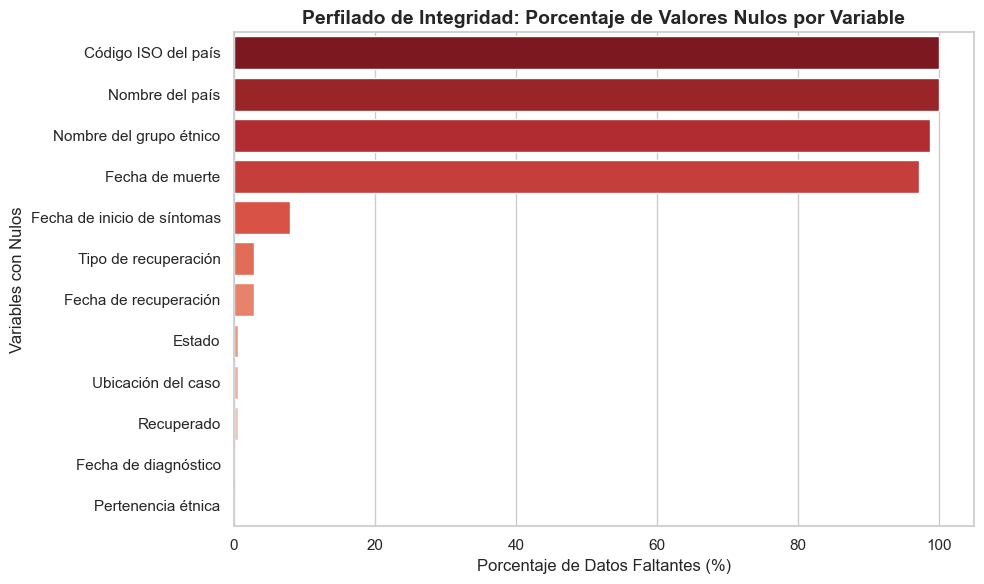

In [38]:
# Configuración visual global
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Calcular el porcentaje de nulos por columna
porcentaje_nulos = (data_covid.isnull().sum() / len(data_covid)) * 100

# 2. Filtrar solo las columnas que tienen algún valor nulo y ordenarlas
nulos_filtrados = porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False)

# 3. Crear la gráfica (CÓDIGO ACTUALIZADO PARA SEABORN MODERNO)
plt.figure(figsize=(10, 6))
sns.barplot(
    x=nulos_filtrados.values, 
    y=nulos_filtrados.index, 
    hue=nulos_filtrados.index, 
    palette="Reds_r", 
    legend=False
)

plt.title("Perfilado de Integridad: Porcentaje de Valores Nulos por Variable", fontsize=14, fontweight='bold')
plt.xlabel("Porcentaje de Datos Faltantes (%)")
plt.ylabel("Variables con Nulos")
plt.tight_layout()
plt.show()

<h3>📊 Análisis de Resultados: Integridad de los Datos (Valores Nulos)</h3>

<p>
    La gráfica de barras generada revela hallazgos críticos sobre la completitud de nuestro dataset. Podemos dividir las variables con nulos en tres categorías de riesgo principales que dictarán nuestras acciones en la fase de limpieza:
</p>

<h4 style="color: #2980b9;">1. Nivel Crítico (Casi 100% de datos faltantes)</h4>
<ul>
    <li><b>Código ISO del país & Nombre del país:</b> Tienen prácticamente el 100% de los datos nulos. Al ser un dataset de casos en Colombia, estas variables son redundantes y candidatas ideales a ser <b>eliminadas (dadas de baja)</b>.</li>
    <li><b>Nombre del grupo étnico:</b> Supera el 95% de vacíos, lo que indica que esta información rara vez fue recolectada en los centros de salud.</li>
    <li><b>Fecha de muerte:</b> Tiene una tasa altísima de valores nulos (cercana al 96-97%). Sin embargo, este es un <b>nulo con significado lógico</b>: el vacío representa que el paciente sobrevivió, por lo que no debe eliminarse la columna, sino entenderse dentro del contexto clínico.</li>
</ul>

<h4 style="color: #2980b9;">2. Nivel Moderado (Menos del 10% de datos faltantes)</h4>
<ul>
    <li><b>Fecha de inicio de síntomas, Tipo de recuperación y Fecha de recuperación:</b> Presentan barras pequeñas. Estos vacíos pueden deberse a pacientes asintomáticos, casos aún activos o fallas de seguimiento temporal.</li>
</ul>

<h4 style="color: #2980b9;">3. Nivel Leve (Mínimos datos faltantes)</h4>
<ul>
    <li>Variables como <b>Estado, Ubicación del caso, Recuperado, Fecha de diagnóstico y Pertenencia étnica</b> muestran barras casi invisibles (cercanas al 0%). Esto indica una calidad de recolección excelente para estas métricas esenciales, y los pocos nulos podrán ser imputados o descartados fácilmente.</li>
</ul>

<h3>📈 Perfilado Numérico: Distribución y Detección de Valores Atípicos</h3>

<p>
    Este bloque de código tiene como objetivo realizar un <b>análisis univariado profundo</b> de la variable <code>Edad</code>. Al ser la principal variable numérica continua del dataset, combinamos dos de las herramientas gráficas más potentes en estadística descriptiva para entender su estructura y evaluar la veracidad de sus registros.
</p>

<h4 style="color: #2980b9;">🎯 ¿Qué esperamos visualizar en estas gráficas?</h4>
<ul>
    <li><b style="color: #2980b9;">1. Histograma con curva KDE (Izquierda):</b> Nos mostrará la forma general de la distribución demográfica de los casos. Esperamos identificar visualmente el "pico" de contagios (el grupo etario más afectado) y observar cómo la frecuencia disminuye hacia las edades más avanzadas.</li>
    <li><b style="color: #2980b9;">2. Diagrama de Caja o Boxplot (Derecha):</b> Su objetivo principal en el perfilado de datos es la <b>detección de anomalías</b>. La "caja" agrupará el 50% central de los pacientes, mientras que cualquier punto que se dibuje por fuera de los "bigotes" (las líneas extremas) nos alertará de valores atípicos (<i>outliers</i>). Esto es vital para descubrir posibles errores de digitación en el Ministerio de Salud, como edades negativas o pacientes registrados con más de 115 años.</li>
</ul>

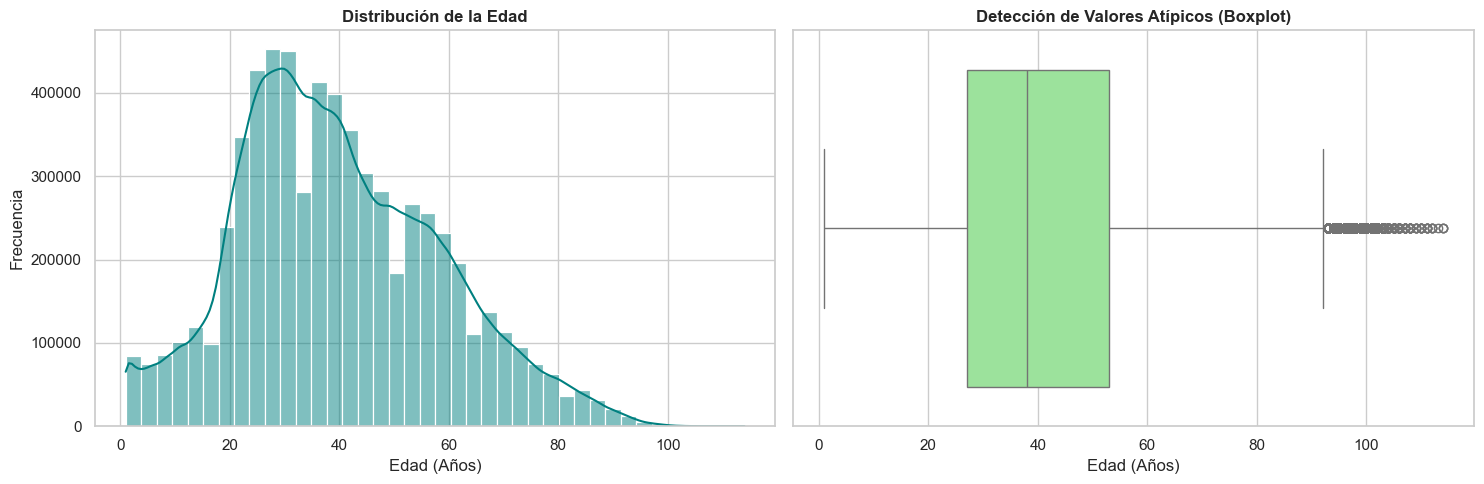

In [33]:
# Crear una figura con dos subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subgráfica 1: Histograma (Distribución general)
sns.histplot(data_covid['Edad'], bins=40, kde=True, color='teal', ax=axes[0])
axes[0].set_title("Distribución de la Edad", fontweight='bold')
axes[0].set_xlabel("Edad (Años)")
axes[0].set_ylabel("Frecuencia")

# Subgráfica 2: Boxplot (Detección de Outliers)
sns.boxplot(x=data_covid['Edad'], color='lightgreen', ax=axes[1])
axes[1].set_title("Detección de Valores Atípicos (Boxplot)", fontweight='bold')
axes[1].set_xlabel("Edad (Años)")

plt.tight_layout()
plt.show()

<h3>📊 Análisis de Resultados: Distribución de Edad y Valores Atípicos</h3>

<p>
    La evaluación univariada de la variable <code>Edad</code> revela hallazgos demográficos y de calidad de datos muy interesantes sobre la población afectada:
</p>

<h4 style="color: #2980b9;">1. Histograma (Distribución Demográfica)</h4>
<ul>
    <li><b>Asimetría positiva (Sesgo a la derecha):</b> La curva no tiene forma de campana perfecta, sino que se inclina fuertemente hacia la izquierda. Esto nos indica que el mayor volumen de casos se concentra en la población joven y adulta joven.</li>
    <li><b>Pico epidémico (Moda):</b> El volumen más alto de contagios registrados se encuentra en el rango aproximado de los <b>25 a los 40 años</b>.</li>
    <li>Observamos una caída constante en el número de casos a medida que la edad avanza (lo cual tiene sentido por la pirámide poblacional).</li>
</ul>

<h4 style="color: #2980b9;">2. Boxplot (Detección de Outliers)</h4>
<ul>
    <li><b>Concentración central:</b> La "caja" verde (el 50% central de los datos) se ubica aproximadamente entre los 25 y los 55 años, con una mediana (la línea divisoria dentro de la caja) cercana a los 35-40 años.</li>
    <li><b>Valores Atípicos (Puntos grises):</b> Existen múltiples puntos estadísticamente atípicos a la derecha del gráfico, correspondientes a pacientes <b>mayores de 90 años, llegando incluso a registros de más de 110 años</b>. </li>
    <li><b>Calidad del dato:</b> ¡Buenas noticias! No se observan atípicos ilógicos (como edades negativas o pacientes de 200 años). Los atípicos observados son biológicamente posibles, por lo que <b>no representan errores de digitación</b>, sino simplemente la cola extrema de la población de la tercera edad afectada por el virus.</li>
</ul>

<h3>🧹 Perfilado Categórico: Análisis de Consistencia y Detección de Ruido</h3>

<p>
    Este bloque de código evalúa la <b>calidad de los datos ingresados manualmente</b> en dos de las variables categóricas más importantes: <code>Sexo</code> y <code>Estado</code>. Nuestro objetivo principal es descubrir inconsistencias tipográficas (ruido) que deban ser estandarizadas en la fase de limpieza.
</p>

<h4 style="color: #2980b9;">🔎 ¿Qué esperamos visualizar y por qué usamos escala logarítmica?</h4>
<ul>
    <li><b style="color: #2980b9;">El superpoder de la Escala Logarítmica:</b> Como las categorías correctas tienen millones de registros y los errores tipográficos pueden tener solo 5 o 10, una gráfica normal haría que los errores fueran invisibles (aplastados contra el eje cero). La escala <code>log</code> nos permite ver "barras enanas" al lado de "barras gigantes", revelando la basura oculta en los datos.</li>
    <li><b style="color: #2980b9;">Gráfica Izquierda ('Sexo'):</b> Esperamos ver las barras dominantes para Masculino (M) y Femenino (F), pero prestaremos mucha atención a la aparición de pequeñas barras correspondientes a letras minúsculas ('m', 'f') u otros caracteres no identificados.</li>
    <li><b style="color: #2980b9;">Gráfica Derecha ('Estado'):</b> Al ordenarse por frecuencia, veremos los estados clínicos más comunes en la parte superior. Visualmente buscaremos duplicidades causadas por el uso mixto de mayúsculas y minúsculas (por ejemplo, tener una barra para 'Leve', otra para 'LEVE' y otra para 'leve').</li>
</ul>

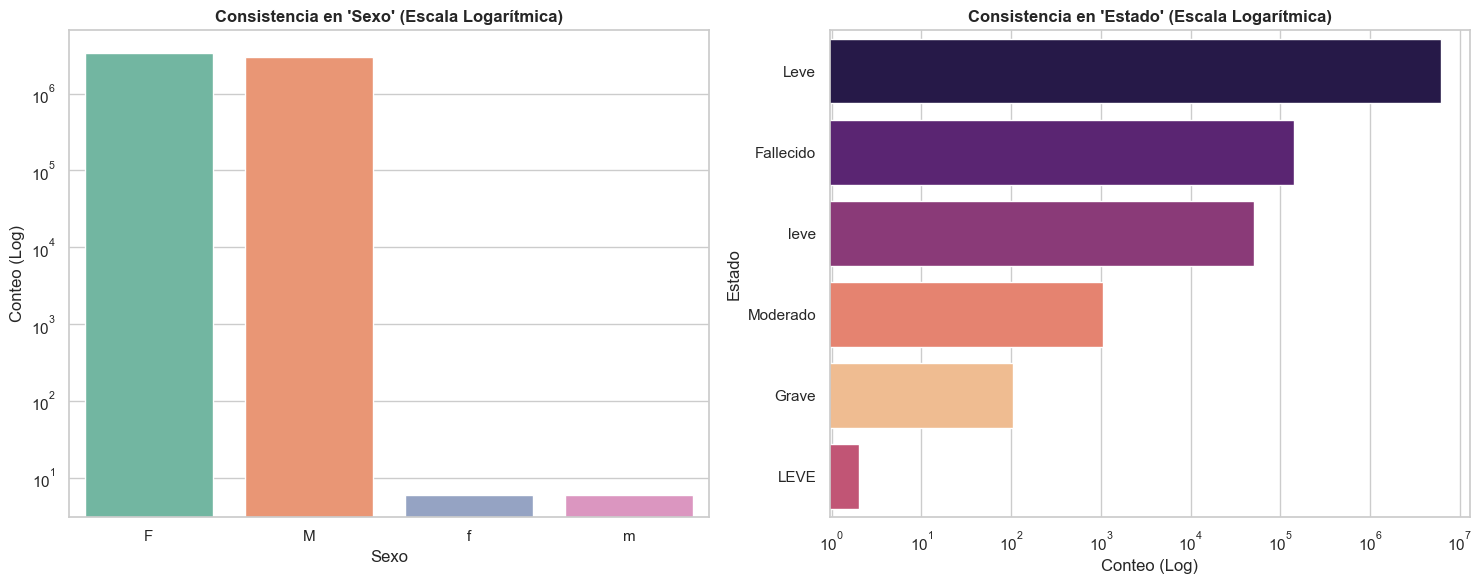

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subgráfica 1: Ruido en la variable 'Sexo'
sns.countplot(
    data=data_covid, 
    x='Sexo', 
    ax=axes[0], 
    palette="Set2", 
    order=data_covid['Sexo'].value_counts().index,
    hue='Sexo',
    legend=False
)
axes[0].set_title("Consistencia en 'Sexo' (Escala Logarítmica)", fontweight='bold')
axes[0].set_yscale('log') # Escala logarítmica para visibilizar los errores menores
axes[0].set_ylabel("Conteo (Log)")

# Subgráfica 2: Ruido en la variable 'Estado'
sns.countplot(
    data=data_covid, 
    y='Estado', 
    ax=axes[1], 
    palette="magma", 
    order=data_covid['Estado'].value_counts().index,
    hue='Estado',
    legend=False
)
axes[1].set_title("Consistencia en 'Estado' (Escala Logarítmica)", fontweight='bold')
axes[1].set_xscale('log') # Escala logarítmica
axes[1].set_xlabel("Conteo (Log)")

plt.tight_layout()
plt.show()

<h3>📊 Análisis de Resultados: Consistencia Categórica y Ruido</h3>

<p>
    La visualización en escala logarítmica ha cumplido su propósito de manera excepcional: ha sacado a la luz los errores tipográficos que estaban "escondidos" bajo el peso de millones de registros correctos. Esto nos marca una hoja de ruta clara para la fase de estandarización:
</p>

<h4 style="color: #2980b9;">1. Inconsistencias en 'Sexo'</h4>
<ul>
    <li><b>Dominancia esperada:</b> Vemos claramente que casi la totalidad de los datos se agrupan correctamente en las categorías en mayúscula <b>'F'</b> (Femenino) y <b>'M'</b> (Masculino), ambas superando el millón de registros.</li>
    <li><b>Ruido detectado:</b> Aparecen dos barras diminutas correspondientes a <b>'f'</b> y <b>'m'</b> en minúscula. Aunque son muy pocos casos, para un modelo de Machine Learning o un reporte de BI, 'F' y 'f' son dos cosas totalmente distintas. Deberemos aplicar una función matemática o de texto para convertir todo a mayúsculas.</li>
</ul>

<h4 style="color: #2980b9;">2. Inconsistencias en 'Estado'</h4>
<ul>
    <li><b>Fractura de categorías:</b> Esta variable presenta un problema de consistencia severo. El estado clínico más común, que debería ser uno solo, está fracturado en tres categorías distintas debido a la falta de validación en la captura de datos: <b>'Leve'</b>, <b>'leve'</b> (todo en minúscula con una cantidad alarmantemente alta de registros) y <b>'LEVE'</b> (todo en mayúscula).</li>
    <li><b>Impacto:</b> Si calculáramos estadísticas agrupadas ahora mismo, los pacientes con estado 'leve' se ignorarían del grupo principal 'Leve'. Es obligatorio estandarizar esta columna aplicando un formato tipo Título (Title Case) para unificar todas estas variantes.</li>
</ul>

<h3>📅 Perfilado Temporal: Análisis de Consistencia Histórica</h3>

<p>
    Este bloque de código realiza una <b>auditoría de las fechas</b> registradas en el dataset. Dado que la <code>Fecha de diagnóstico</code> se cargó originalmente como texto plano (<code>str</code>), el primer paso es forzar su conversión a un formato temporal oficial de Pandas (<code>datetime</code>). Esto nos permite agrupar los millones de registros por <b>Año y Mes</b> para construir una línea de tiempo real.
</p>

<h4 style="color: #2980b9;">⏱️ ¿Qué esperamos visualizar e identificar en esta serie de tiempo?</h4>
<ul>
    <li><b style="color: #2980b9;"">La Curva Epidémica:</b> Observaremos visualmente los "picos" históricos o las famosas olas de contagio de COVID-19 en Colombia a lo largo del tiempo.</li>
    <li><b style="color: #2980b9;"">Anomalías Temporales (Outliers de Fechas):</b> La gráfica nos revelará de inmediato si existen fechas ilógicas. Si observamos puntos dibujados en años como 1900, 2018 (antes de la pandemia) o años en el futuro, tendremos la certeza de que existen errores graves de digitación que deben ser tratados.</li>
    <li><b style="color: #2980b9;"">Gestión de Errores de Formato:</b> Al utilizar el parámetro <code>errors='coerce'</code>, nos aseguramos de que cualquier "texto basura" introducido por error en la columna de fechas se convierta automáticamente en un nulo temporal (NaT), evitando que el código colapse.</li>
</ul>

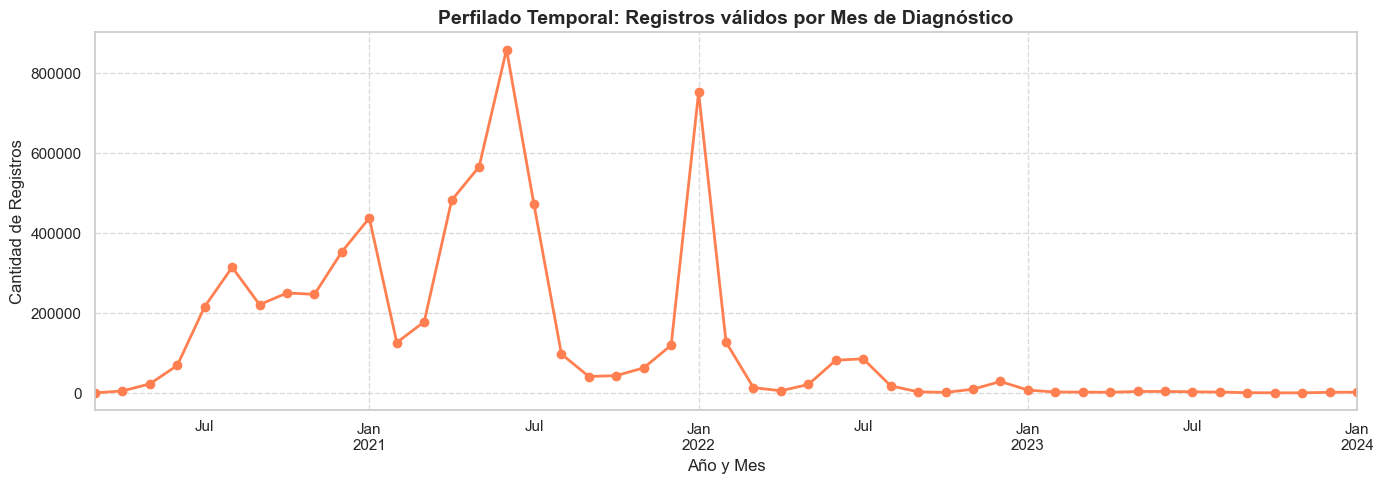

In [35]:
# 1. Convertir la columna de texto a formato fecha (datetime)
# Usamos 'coerce' para que los errores de formato se conviertan en NaT (Not a Time)
fechas = pd.to_datetime(data_covid['Fecha de diagnóstico'], errors='coerce')

# 2. Extraer el formato de "Año-Mes" para ver el volumen mensual
casos_por_mes = fechas.dt.to_period('M').value_counts().sort_index()

# 3. Crear la gráfica de línea de tiempo
plt.figure(figsize=(14, 5))
casos_por_mes.plot(kind='line', marker='o', color='coral', linewidth=2)

plt.title("Perfilado Temporal: Registros válidos por Mes de Diagnóstico", fontsize=14, fontweight='bold')
plt.xlabel("Año y Mes")
plt.ylabel("Cantidad de Registros")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<h3>📉 Análisis de Resultados: Curva Epidémica y Calidad Temporal</h3>

<p>
    La gráfica de serie de tiempo nos ofrece una perspectiva histórica clara del comportamiento del virus y, lo más importante para nuestro perfilado, valida la integridad cronológica de los registros:
</p>

<h4 style="color: #2980b9;">1. Las Olas de Contagio (Tendencia Histórica)</h4>
<ul>
    <li><b>Identificación de picos críticos:</b> La línea temporal refleja perfectamente las distintas "olas" de la pandemia. Se observa un pico masivo a mediados de 2021 (superando los 800,000 registros mensuales) y otro muy pronunciado y abrupto a inicios de 2022 (coincidiendo con la llegada de la variante Ómicron).</li>
    <li><b>Estabilización:</b> A partir de la segunda mitad de 2022, la curva cae y se aplana drásticamente, manteniéndose muy baja durante 2023 y principios de 2024, lo que representa el fin de la etapa crítica de la emergencia sanitaria.</li>
</ul>

<h4 style="color: #2980b9;">2. Calidad de los Datos (Outliers Temporales)</h4>
<ul>
    <li><b>Consistencia cronológica:</b> ¡Excelentes noticias! El eje X comienza lógicamente a principios de 2020 y finaliza en 2024. No se observan puntos dibujados en años imposibles (como 1990 o 2050), lo que indica que no hay errores tipográficos graves en el año de registro que distorsionen el análisis histórico.</li>
</ul>